# Soybean Rust (SBR) Early Warning — Notebook 1 (v2): Data, Multi-source Weather & First Model

This notebook follows the decisions from **Meeting 2 (15 Sept 2026)**:

| Decision in the minutes | Where it is in this notebook |
|---|---|
| Target = rust severity on the **1–5 scale** | Section 2 (zero handling) and Section 7 |
| Investigate **zero** severity values | Section 2 |
| Average replicates by location × genotype × season | Section 4 |
| Plots of severity by year, location, genotype, etc. | Section 3 |
| Use **sowing dates** to estimate the symptom date | Section 5 (growth-stage estimation) |
| **ERA5** weather at the exact trial coordinates, plus higher-resolution sources to compare | Section 6: ERA5 (25 km), ERA5-Land (11 km), ECMWF IFS (9 km), CHIRPS rainfall (5 km) — all free, no API key |
| Which source predicts rust best? | Section 7 |
| Predictors from the **14 days before** the estimated symptom date | Section 6 |
| Literature-based variables (leaf wetness, Tmin/Tmax, rain, radiation, wind, soil moisture, VPD) | Section 6 |
| **Time-based validation** (train on earlier years, test on later years) | Section 7 |

**How to run:** `Runtime → Run all`. When asked, upload `Soybean_Rust_PAT_database_MT2.csv`.
The weather download (Section 6) takes a few minutes the first time; results are cached so re-runs are fast.

## 0. Setup and settings

In [11]:
import os, time, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
plt.rcParams['figure.dpi'] = 110

# ---------------- SETTINGS (change these, then re-run) ----------------
CSV_PATH      = 'Soybean_Rust_PAT_database_MT2.csv'
ZERO_HANDLING = 'as_no_rust'   # 'as_no_rust' -> 0 becomes 1 ; 'drop' -> rows with 0 removed
ANCHOR_STAGE  = 'R4'           # estimated symptom date used for the 14-day window: 'R4' or 'R6'
WINDOW_DAYS   = 14             # length of the pre-symptom weather window (minutes: 14 days)
ENV_TARGET    = 'mean'         # environment severity: 'mean' of all genotypes, or 'p90' (disease pressure on susceptible lines)
SOURCES = {                    # label : Open-Meteo model name (hourly data)
    'ERA5 (25 km)':      'era5',
    'ERA5-Land (11 km)': 'era5_seamless',  # ERA5-Land temp/humidity/soil + ERA5 rain/wind/radiation
    'IFS (9 km)':        'ecmwf_ifs',      # ECMWF operational model, 2017 onwards
}
USE_CHIRPS    = True           # also build 'IFS (9 km) + CHIRPS rain (5 km)'
CACHE_DIR     = 'weather_cache'

# Epidemiological thresholds (Favoretto et al. 2025, citing Melching et al. 1989):
T_LOW, T_HIGH  = 17, 29        # temperature range favourable for infection (deg C)
RH_WET         = 90            # hours with RH >= 90% used as a leaf-wetness proxy
MIN_WET_HOURS  = 6             # minimum wet hours in a day for an 'infection-favourable' day
os.makedirs(CACHE_DIR, exist_ok=True)

In [12]:
# Upload the CSV if it is not already in the Colab session
if not os.path.exists(CSV_PATH):
    try:
        from google.colab import files
        print('Please upload', CSV_PATH)
        up = files.upload()
        CSV_PATH = list(up.keys())[0]
    except ImportError:
        raise FileNotFoundError(f'{CSV_PATH} not found. Put it next to this notebook.')
print('Using', CSV_PATH)

Please upload Soybean_Rust_PAT_database_MT2.csv


Saving Soybean_Rust_PAT_database_MT2.csv to Soybean_Rust_PAT_database_MT2.csv
Using Soybean_Rust_PAT_database_MT2.csv


## 1. Load and clean the data

In [13]:
raw = pd.read_csv("/content/Soybean_Rust_PAT_database_MT2.csv")
df = raw.copy()
df['SOWING']  = pd.to_datetime(df['SOWING'],  format='%d/%m/%Y', errors='coerce')
df['HARVEST'] = pd.to_datetime(df['HARVEST'], format='%d/%m/%Y', errors='coerce')

# Harvest recorded before sowing = year typo -> add one year (check with data manager)
bad = df['HARVEST'] < df['SOWING']
print('Rows with harvest before sowing (fixed by +1 year):', bad.sum(), df.loc[bad, 'env'].unique())
df.loc[bad, 'HARVEST'] += pd.DateOffset(years=1)

# In phenology/yield traits, 0 means 'not recorded' -> NaN
for c in ['FLW_DAYS', 'NDM', 'W100G', 'PH_R8']:
    df[c] = df[c].replace(0, np.nan)

df = df.rename(columns={'R6_RUST_Se': 'rust'})
print(df.shape)
print('Countries:', df.COUNTRY.value_counts().to_dict())
print('Environments:', df.env.nunique(), '| Locations:', df['loc'].nunique(), '| Genotypes:', df.gen.nunique())
df.head()

Rows with harvest before sowing (fixed by +1 year): 0 []
(3653, 41)
Countries: {'Malawi': 2363, 'Zambia': 1210, 'Tanzania': 80}
Environments: 101 | Locations: 45 | Genotypes: 175


,COUNTRY,YEAR,env,gen,loc,SEASON,check,PL_EMERG_C,PL_EMERG_P,FLW_DAYS,FLW_CL,PUB_CL,NDM,LOD,PODDING_MA,Pod_Shatte,PH_R8,W100G,GY,R6_BB_Sev,R6_BP_Sev,R6_BS_Sev,R6_BTS_Sev,R6_CLB_Sev,R6_DM_Sev,R6_MLS_Sev,R6_FELS_Se,R6_RLB_Sev,rust,R6_RUST_RR,R6_Others_,PROT,OIL,SOWING,HARVEST,LAT,LON,ELEV,RAINFED,SOURCE,COMPANY
0,Malawi,2017,E016,G003,L011,2,0,0.0,0.0,66.666667,NaN,NaN,128.666667,1,0.0,1.000000,NaN,10.000000,806.286667,1,1,0,0,0,0,0,2,0,3,0,2,44.423333,18.270000,2017-12-18,NaT,-13.983,33.633,1097.0,Rainfed,Savanna Agricultural Research Institute CSIRSARI,Public
1,Malawi,2017,E016,G031,L011,2,0,0.0,0.0,63.666667,NaN,NaN,131.000000,3,0.0,1.333333,NaN,11.666667,1014.886667,1,1,0,0,0,0,0,1,0,2,0,1,44.840000,17.726667,2017-12-18,NaT,-13.983,33.633,1097.0,Rainfed,Savanna Agricultural Research Institute CSIRSARI,Public
2,Malawi,2017,E016,G034,L011,2,0,0.0,0.0,52.666667,NaN,NaN,119.666667,1,0.0,1.333333,NaN,10.000000,1597.840000,3,1,0,0,0,0,0,1,0,3,0,1,41.496667,21.893333,2017-12-18,NaT,-13.983,33.633,1097.0,Rainfed,ZamSeed,Private
3,Malawi,2017,E016,G056,L011,2,0,0.0,0.0,47.666667,NaN,NaN,117.000000,1,0.0,1.333333,NaN,15.000000,1627.500000,1,1,0,0,0,0,0,1,0,1,0,1,38.610000,22.963333,2017-12-18,NaT,-13.983,33.633,1097.0,Rainfed,ZamSeed,Private
4,Malawi,2017,E016,G059,L011,2,0,0.0,0.0,54.666667,NaN,NaN,112.000000,1,0.0,1.000000,NaN,16.666667,1498.723333,1,1,0,0,0,0,0,1,0,1,0,1,41.620000,19.820000,2017-12-18,NaT,-13.983,33.633,1097.0,Rainfed,Makerere University,Public


## 2. Investigating the zero severity values

The PAT protocol (Favoretto et al. 2025, Fig. 1) uses **1 = no visible symptoms … 5 = 66–100% of leaf area**.
There is no 0 on that scale. Three patterns can tell us what a 0 means:

* **Whole trial = 0** → rust was not seen in that trial. If other diseases *were* scored there, 0 most likely means "no rust", not "not assessed".
* **0 mixed with 2–5 but no 1s** → that trial used a 0–5 style where 0 = no symptoms.
* **A few 0s among many 1s** → probably individual missing plots.

In [14]:
env_rng = df.groupby('env')['rust'].agg(['min', 'max', 'size'])
env_rng['n_zero'] = df.groupby('env')['rust'].apply(lambda s: (s == 0).sum())
env_rng['n_one']  = df.groupby('env')['rust'].apply(lambda s: (s == 1).sum())

def zero_pattern(r):
    if r['n_zero'] == 0:                 return 'no zeros'
    if r['max'] == 0:                    return 'whole trial = 0'
    if r['n_one'] == 0:                  return '0 used instead of 1'
    return 'few 0s among 1s'
env_rng['zero_pattern'] = env_rng.apply(zero_pattern, axis=1)
print(env_rng['zero_pattern'].value_counts(), '\n')

# Were OTHER diseases scored in the all-zero trials? (if yes, the trial was assessed)
other = [c for c in df.columns if c.startswith('R6_') and c not in ('R6_RUST_RR',)]
allzero_envs = env_rng.index[env_rng.zero_pattern == 'whole trial = 0']
assessed = df[df.env.isin(allzero_envs)].groupby('env')[other].max().gt(0).any(axis=1)
print(f'All-zero trials where at least one other disease was scored: {assessed.sum()} of {len(assessed)}')
env_rng[env_rng.zero_pattern.isin(['0 used instead of 1', 'few 0s among 1s'])]

zero_pattern
no zeros               60
whole trial = 0        26
few 0s among 1s        12
0 used instead of 1     3
Name: count, dtype: int64 

All-zero trials where at least one other disease was scored: 3 of 26


,min,max,size,n_zero,n_one,zero_pattern
env,,,,,,
E0138,0,1,50,1,49,few 0s among 1s
E016,0,4,36,1,15,few 0s among 1s
E017,0,2,36,2,31,few 0s among 1s
E018,0,2,36,1,34,few 0s among 1s
E0229,0,3,40,6,30,few 0s among 1s
E0230,0,5,40,26,0,0 used instead of 1
E0248,0,2,40,2,31,few 0s among 1s
E0249,0,5,40,34,0,0 used instead of 1
E0251,0,5,40,5,8,few 0s among 1s


In [15]:
if ZERO_HANDLING == 'as_no_rust':
    df['rust'] = df['rust'].replace(0, 1)
elif ZERO_HANDLING == 'drop':
    df = df[df['rust'] > 0].copy()
print('Severity distribution after zero handling:')
print(df['rust'].value_counts().sort_index())

Severity distribution after zero handling:
rust
1    2956
2     288
3     250
4     124
5      35
Name: count, dtype: int64


## 3. Exploratory plots (severity by year, country, season, location, genotype)

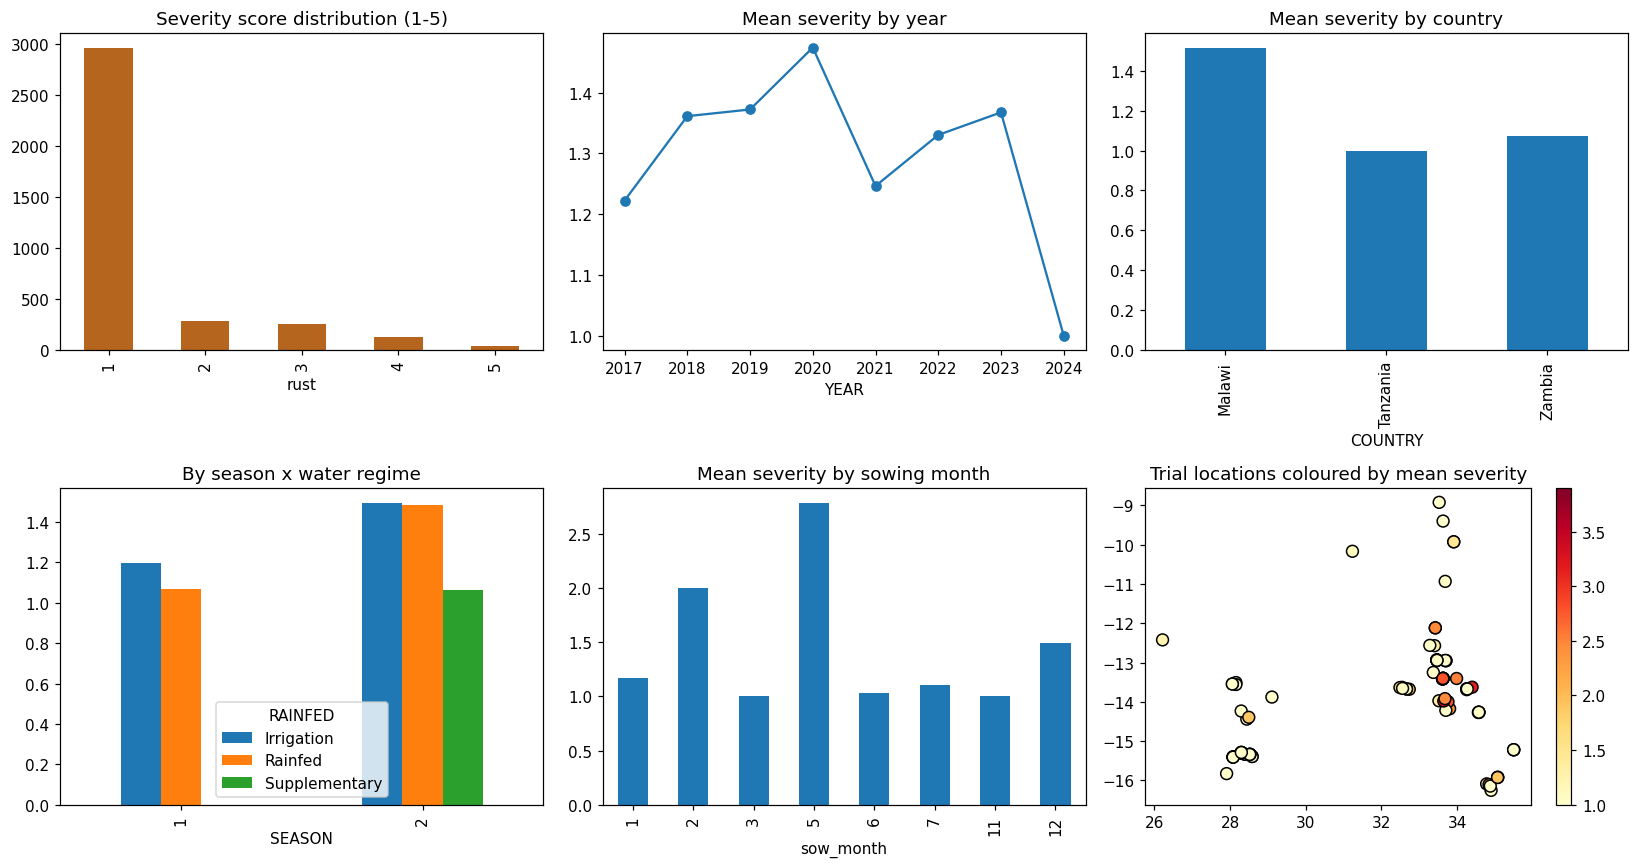

In [16]:
fig, ax = plt.subplots(2, 3, figsize=(15, 8))
df['rust'].value_counts().sort_index().plot.bar(ax=ax[0,0], color='#b5651d'); ax[0,0].set_title('Severity score distribution (1-5)')
df.groupby('YEAR')['rust'].mean().plot(marker='o', ax=ax[0,1]); ax[0,1].set_title('Mean severity by year')
df.groupby('COUNTRY')['rust'].mean().plot.bar(ax=ax[0,2]); ax[0,2].set_title('Mean severity by country')
df.groupby(['SEASON','RAINFED'])['rust'].mean().unstack().plot.bar(ax=ax[1,0]); ax[1,0].set_title('By season x water regime')
df['sow_month'] = df['SOWING'].dt.month
df.groupby('sow_month')['rust'].mean().plot.bar(ax=ax[1,1]); ax[1,1].set_title('Mean severity by sowing month')
e = df.groupby('env').agg(lat=('LAT','first'), lon=('LON','first'), sev=('rust','mean'))
sc = ax[1,2].scatter(e.lon, e.lat, c=e.sev, cmap='YlOrRd', s=60, edgecolor='k'); plt.colorbar(sc, ax=ax[1,2])
ax[1,2].set_title('Trial locations coloured by mean severity')
plt.tight_layout(); plt.show()

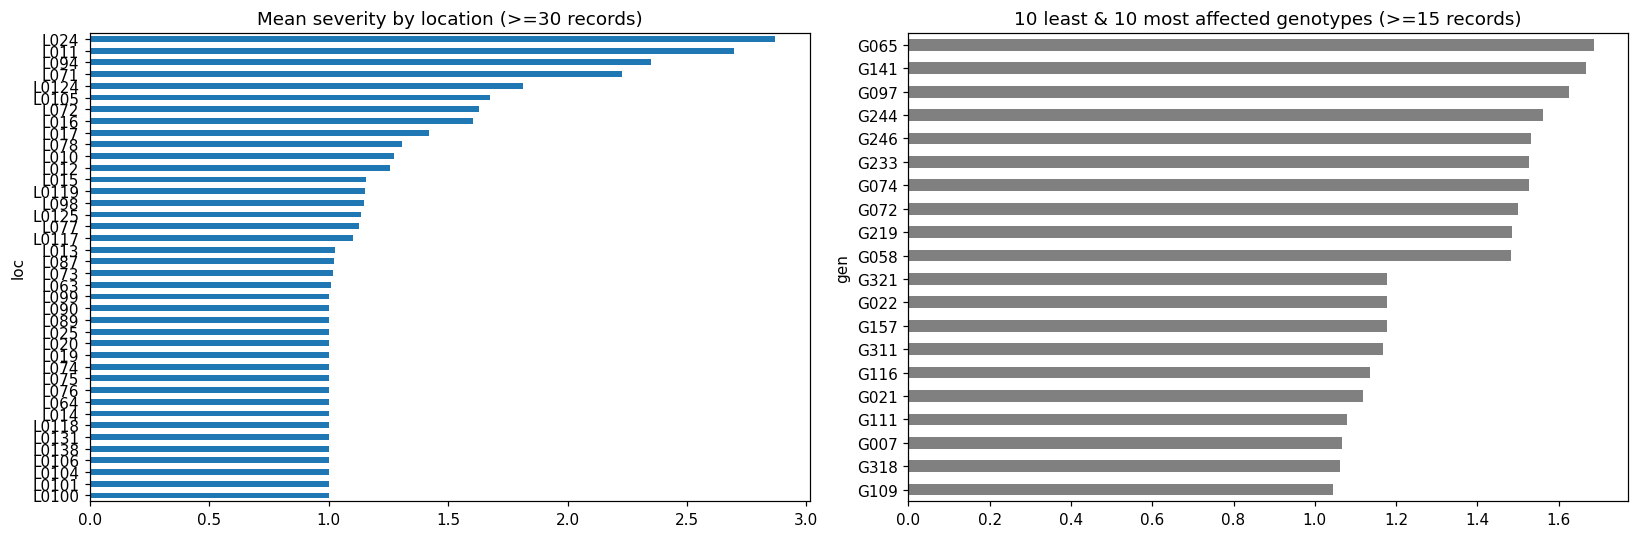

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
loc_s = df.groupby('loc')['rust'].agg(['mean','size']).query('size >= 30').sort_values('mean')
loc_s['mean'].plot.barh(ax=ax[0]); ax[0].set_title('Mean severity by location (>=30 records)')
gen_s = df.groupby('gen')['rust'].agg(['mean','size']).query('size >= 15').sort_values('mean')
pd.concat([gen_s.head(10), gen_s.tail(10)])['mean'].plot.barh(ax=ax[1], color='gray')
ax[1].set_title('10 least & 10 most affected genotypes (>=15 records)')
plt.tight_layout(); plt.show()

## 4. Aggregation

* **Genotype level** – replicates averaged by country × location × season × year × genotype (the file already has one row per genotype per environment; this step also checks for duplicates).
* **Environment level** – weather is the same for every genotype in a trial, so the early-warning model is first built on one row per environment (site × season).

In [18]:
keys = ['COUNTRY', 'loc', 'env', 'YEAR', 'SEASON', 'gen']
print('Duplicate genotype x environment records:', df.duplicated(keys).sum())
geno = (df.groupby(keys, as_index=False)
          .agg(rust=('rust', 'mean'), GY=('GY', 'mean'), FLW_DAYS=('FLW_DAYS', 'mean'), NDM=('NDM', 'mean'),
               LAT=('LAT', 'first'), LON=('LON', 'first'), SOWING=('SOWING', 'first'), HARVEST=('HARVEST', 'first')))

def p90(s): return s.quantile(0.9)
env = (df.groupby('env')
         .agg(country=('COUNTRY','first'), loc=('loc','first'), year=('YEAR','first'), season=('SEASON','first'),
              water=('RAINFED','first'), lat=('LAT','first'), lon=('LON','first'), elev=('ELEV','first'),
              sowing=('SOWING','min'), harvest=('HARVEST','max'),
              flw_days=('FLW_DAYS','median'), ndm=('NDM','median'), n_gen=('gen','nunique'),
              sev_mean=('rust','mean'), sev_p90=('rust', p90), sev_max=('rust','max'))
         .reset_index())
env['severity'] = env['sev_mean'] if ENV_TARGET == 'mean' else env['sev_p90']
print(env.shape); env.describe().T[['mean','min','max']]

Duplicate genotype x environment records: 0
(101, 18)


,mean,min,max
year,2020.287129,2017.0,2024.0
season,1.762376,1.0,2.0
lat,-13.925941,-16.254,-8.921
lon,32.045713,26.217,35.496
elev,1008.321782,64.0,1795.0
sowing,2021-02-22 08:33:16.039603968,2017-12-18 00:00:00,2025-01-03 00:00:00
harvest,NaT,NaT,NaT
flw_days,51.838918,35.0,84.0
ndm,111.757699,85.333333,160.0
n_gen,36.168317,25.0,50.0


## 5. Estimating growth stages and the symptom date

Only sowing date, days to flowering (R1) and days to maturity (NDM ≈ R8) are recorded. R4 and R6 are estimated using the
**relative position** of the stages in the Manitoba *Soybean Plant Development Guide*
(R1 = 45 d, R4 = 70 d, R6 = 90 d, R8 = 120 d after planting):

* R4 = R1 + (R8 − R1) × (70 − 45)/(120 − 45) = R1 + **0.33** × (R8 − R1)
* R6 = R1 + (R8 − R1) × (90 − 45)/(120 − 45) = R1 + **0.60** × (R8 − R1)

The Manitoba days themselves are **not** used directly, because these tropical PAT varieties flower at ~49 days and mature at ~108 days,
faster than in Manitoba. Note: in the guide, **45 days after planting corresponds to R1, not R4** (see the minutes' 45-day question).

In [19]:
MED_R1 = env['flw_days'].median()
MED_R8 = env['ndm'].median()
env['R1_days'] = env['flw_days'].fillna(MED_R1)
env['R8_days'] = env['ndm'].fillna(MED_R8)
env.loc[env['R8_days'] <= env['R1_days'] + 20, 'R8_days'] = env['R1_days'] + (MED_R8 - MED_R1)  # guard against bad values
env['R4_days'] = env['R1_days'] + 0.33 * (env['R8_days'] - env['R1_days'])
env['R6_days'] = env['R1_days'] + 0.60 * (env['R8_days'] - env['R1_days'])
for s in ['R1', 'R4', 'R6', 'R8']:
    env[f'{s}_date'] = env['sowing'] + pd.to_timedelta(env[f'{s}_days'].round(), unit='D')
print(f'Median days after sowing  R1={env.R1_days.median():.0f}  R4={env.R4_days.median():.0f}  '
      f'R6={env.R6_days.median():.0f}  R8={env.R8_days.median():.0f}')
env[['env','sowing','R1_date','R4_date','R6_date','R8_date','severity']].head()

Median days after sowing  R1=49  R4=69  R6=86  R8=110


,env,sowing,R1_date,R4_date,R6_date,R8_date,severity
0,E0103,2019-12-14,2020-02-02,2020-02-19,2020-03-04,2020-03-25,1.000
1,E0104,2019-12-24,2020-02-05,2020-02-26,2020-03-14,2020-04-08,1.000
2,E0105,2019-12-05,2020-01-22,2020-02-14,2020-03-03,2020-03-31,1.000
3,E0106,2019-12-18,2020-02-01,2020-02-21,2020-03-09,2020-04-04,1.000
4,E0107,2019-12-30,2020-02-18,2020-03-06,2020-03-20,2020-04-11,1.125


## 6. Weather from several sources at different resolutions

Three hourly model datasets are downloaded from the free **Open-Meteo Historical Weather API**, and daily rainfall from **CHIRPS**:

| Label | Source | Spatial | Temporal | Coverage | Access |
|---|---|---|---|---|---|
| ERA5 (25 km) | ECMWF ERA5 reanalysis | 0.25° (~25 km) | Hourly | 1940– | Open-Meteo `era5` |
| ERA5-Land (11 km) | ERA5-Land for temperature, humidity and soil moisture; ERA5 for rain, wind and radiation | 0.1° (~11 km) / 0.25° | Hourly | 1950– | Open-Meteo `era5_seamless` |
| IFS (9 km) | ECMWF IFS operational model | 9 km | Hourly | 2017– | Open-Meteo `ecmwf_ifs` |
| IFS (9 km) + CHIRPS (5 km) | IFS for everything except rain; CHIRPS v2 for rain | 9 km / 0.05° (~5.5 km) | Hourly / daily | CHIRPS 1981– | NOAA ERDDAP (no account) |

Open-Meteo selects a land grid cell with elevation similar to the trial (90 m elevation model) and adjusts temperature for elevation.
Only the days needed for the R4 and R6 windows are downloaded, which keeps requests small. Everything is cached, so re-runs are fast.

In [20]:
import io
from urllib.parse import quote

OM_URL  = 'https://archive-api.open-meteo.com/v1/archive'
ERDDAP  = 'https://coastwatch.pfeg.noaa.gov/erddap/griddap/chirps20GlobalDailyP05.csv'
HOURLY  = ['temperature_2m', 'relative_humidity_2m', 'dew_point_2m', 'precipitation', 'shortwave_radiation',
           'wind_speed_10m', 'wind_direction_10m', 'vapour_pressure_deficit', 'soil_moisture_0_to_7cm']

def get_openmeteo(model, env_id, lat, lon, start, end):
    folder = os.path.join(CACHE_DIR, model); os.makedirs(folder, exist_ok=True)
    path, meta_path = f'{folder}/{env_id}.csv', f'{folder}/{env_id}.json'
    if os.path.exists(path):
        return pd.read_csv(path, parse_dates=['time']), json.load(open(meta_path))
    params = dict(latitude=round(lat, 5), longitude=round(lon, 5), models=model,
                  start_date=start.strftime('%Y-%m-%d'), end_date=end.strftime('%Y-%m-%d'),
                  hourly=','.join(HOURLY), timezone='auto', wind_speed_unit='ms', cell_selection='land')
    for attempt in range(5):
        try:
            r = requests.get(OM_URL, params=params, timeout=120)
            if r.status_code == 429:
                time.sleep(30 * (attempt + 1)); continue
            if r.status_code == 400:
                print(f'  {model}/{env_id}: request rejected -> {r.json().get("reason")}'); return None, None
            r.raise_for_status()
            js = r.json()
            h = pd.DataFrame(js['hourly']); h['time'] = pd.to_datetime(h['time'])
            meta = {'grid_lat': js.get('latitude'), 'grid_lon': js.get('longitude'), 'grid_elev': js.get('elevation')}
            h.to_csv(path, index=False); json.dump(meta, open(meta_path, 'w'))
            time.sleep(0.3)
            return h, meta
        except Exception as ex:
            print(f'  {model}/{env_id}: attempt {attempt+1} failed: {ex}'); time.sleep(5 * (attempt + 1))
    return None, None

def get_chirps(env_id, lat, lon, start, end):
    folder = os.path.join(CACHE_DIR, 'chirps'); os.makedirs(folder, exist_ok=True)
    path = f'{folder}/{env_id}.csv'
    if os.path.exists(path):
        return pd.read_csv(path, parse_dates=['date'])
    q = (f'precip[({start:%Y-%m-%d}T00:00:00Z):1:({end:%Y-%m-%d}T00:00:00Z)]'
         f'[({lat:.4f})][({lon:.4f})]')                       # single lat/lon -> nearest 0.05 deg cell
    for attempt in range(4):
        try:
            r = requests.get(ERDDAP + '?' + quote(q, safe=''), timeout=180)
            if r.status_code == 404:                           # dates outside the ERDDAP copy
                print(f'  chirps/{env_id}: no data for these dates'); return None
            r.raise_for_status()
            c = pd.read_csv(io.StringIO(r.text), skiprows=[1])  # 2nd line holds units
            c = pd.DataFrame({'date': pd.to_datetime(c['time']).dt.tz_localize(None).dt.normalize(),
                              'precip': c['precip']})
            c.to_csv(path, index=False)
            time.sleep(0.5)
            return c
        except Exception as ex:
            print(f'  chirps/{env_id}: attempt {attempt+1} failed: {ex}'); time.sleep(10 * (attempt + 1))
    return None

# download window per environment: from (R4 - window) to R6, plus one day either side
env['dl_start'] = env['R4_date'] - pd.Timedelta(days=WINDOW_DAYS + 1)
env['dl_end']   = env['R6_date'] + pd.Timedelta(days=1)

hourly, grid = {m: {} for m in SOURCES.values()}, {m: {} for m in SOURCES.values()}
chirps = {}
for label, model in SOURCES.items():
    print(f'Downloading {label} ...')
    for i, r in env.iterrows():
        hourly[model][r['env']], grid[model][r['env']] = get_openmeteo(model, r['env'], r['lat'], r['lon'], r['dl_start'], r['dl_end'])
    ok = sum(v is not None for v in hourly[model].values())
    print(f'  {label}: {ok}/{len(env)} environments')
if USE_CHIRPS:
    print('Downloading CHIRPS rainfall ...')
    for i, r in env.iterrows():
        chirps[r['env']] = get_chirps(r['env'], r['lat'], r['lon'], r['dl_start'], r['dl_end'])
    print(f'  CHIRPS: {sum(v is not None for v in chirps.values())}/{len(env)} environments')

  ERA5 (25 km): 101/101 environments
  ERA5-Land (11 km): 101/101 environments
  IFS (9 km): 101/101 environments
  chirps/E0139: attempt 1 failed: 503 Server Error:  for url: https://coastwatch.pfeg.noaa.gov/erddap/griddap/chirps20GlobalDailyP05.csv?precip%5B%282020-08-28T00%3A00%3A00Z%29%3A1%3A%282020-09-28T00%3A00%3A00Z%29%5D%5B%28-13.4030%29%5D%5B%2833.6270%29%5D
  chirps/E093: attempt 1 failed: 503 Server Error:  for url: https://coastwatch.pfeg.noaa.gov/erddap/griddap/chirps20GlobalDailyP05.csv?precip%5B%282020-02-04T00%3A00%3A00Z%29%3A1%3A%282020-03-06T00%3A00%3A00Z%29%5D%5B%28-13.9790%29%5D%5B%2833.6450%29%5D
  CHIRPS: 101/101 environments


### Does higher resolution actually separate the trial sites?

With a coarse grid, nearby trials share one grid cell and get identical weather.
This table counts how many **distinct grid cells** the 90 unique trial coordinates fall into, and how far the grid-cell centre is from the trial.

In [21]:
def haversine_km(lat1, lon1, lat2, lon2):
    p = np.pi / 180
    a = np.sin((lat2 - lat1) * p / 2) ** 2 + np.cos(lat1 * p) * np.cos(lat2 * p) * np.sin((lon2 - lon1) * p / 2) ** 2
    return 12742 * np.arcsin(np.sqrt(a))

rows = []
for label, model in SOURCES.items():
    g = pd.DataFrame({e: m for e, m in grid[model].items() if m}).T
    if g.empty: continue
    g = g.join(env.set_index('env')[['lat', 'lon', 'elev']])
    dist = haversine_km(g.lat, g.lon, g.grid_lat.astype(float), g.grid_lon.astype(float))
    rows.append({'source': label,
                 'unique trial sites': g[['lat', 'lon']].drop_duplicates().shape[0],
                 'distinct grid cells': g[['grid_lat', 'grid_lon']].drop_duplicates().shape[0],
                 'median distance to cell centre (km)': round(dist.median(), 1),
                 'median |elevation difference| (m)': round((g.grid_elev.astype(float) - g.elev).abs().median(), 0)})
display(pd.DataFrame(rows))

,source,unique trial sites,distinct grid cells,median distance to cell centre (km),median |elevation difference| (m)
0,ERA5 (25 km),90,38,10.3,8.0
1,ERA5-Land (11 km),90,45,3.8,8.0
2,IFS (9 km),90,48,3.6,8.0


### Predictor features (same epidemiological definitions for every source)

| Feature | Why |
|---|---|
| `wet_hours`, `wet_days6` | Leaf-wetness proxy (RH ≥ 90%); ≥ 6 h wetness needed for infection (Melching et al. 1989) |
| `infect_days` | ≥ 6 wet hours **and** wet-period temperature 17–29 °C (Favoretto et al. 2025) |
| `tmin`, `tmax`, `hot_days`, `hours_T17_29` | Min/max temperature rather than the plain mean; > 30 °C suppresses infection |
| `rain_total`, `rain_days` | Rainfall models of rust severity (Del Ponte et al. 2006) — from CHIRPS in the CHIRPS set |
| `rh_mean`, `vpd_mean` | Air moisture / drying power |
| `srad` | Solar radiation reduces spore survival |
| `wind`, `wind_sin`, `wind_cos` | Spore dispersal; direction as circular components |
| `soilm` | Soil moisture 0–7 cm |

In [22]:
def window_features(h, rain_daily=None):
    '''Summarise hourly weather over one window. rain_daily (optional) replaces model rain, e.g. CHIRPS.'''
    if h is None or h.empty:
        return {}
    h = h.copy()
    h['date'] = h['time'].dt.normalize()
    h['wet'] = (h['relative_humidity_2m'] >= RH_WET).where(h['relative_humidity_2m'].notna())
    d = h.groupby('date').agg(tmin=('temperature_2m', 'min'), tmax=('temperature_2m', 'max'),
                              rain=('precipitation', lambda s: s.sum(min_count=1)),
                              wet_h=('wet', lambda s: s.sum(min_count=1)))
    d['wet_T'] = h[h['wet'] == True].groupby('date')['temperature_2m'].mean().reindex(d.index)
    if rain_daily is not None:
        rd = rain_daily.set_index('date')['precip'].reindex(d.index)
        d['rain'] = rd if rd.notna().mean() >= 0.9 else d['rain']   # fall back to model rain if CHIRPS has gaps
    infect = (d['wet_h'] >= MIN_WET_HOURS) & d['wet_T'].between(T_LOW, T_HIGH)
    nan_if_empty = lambda s, v: v if s.notna().any() else np.nan
    wd = np.deg2rad(h['wind_direction_10m'])
    return {
        'wet_hours':    nan_if_empty(h['wet'], h['wet'].sum()),
        'wet_days6':    nan_if_empty(d['wet_h'], (d['wet_h'] >= MIN_WET_HOURS).sum()),
        'infect_days':  nan_if_empty(d['wet_h'], infect.sum()),
        'tmin':         d['tmin'].mean(),
        'tmax':         d['tmax'].mean(),
        'hot_days':     nan_if_empty(d['tmax'], (d['tmax'] > 30).sum()),
        'hours_T17_29': nan_if_empty(h['temperature_2m'], h['temperature_2m'].between(T_LOW, T_HIGH).sum()),
        'rain_total':   d['rain'].sum(min_count=1),
        'rain_days':    nan_if_empty(d['rain'], (d['rain'] >= 1).sum()),
        'rh_mean':      h['relative_humidity_2m'].mean(),
        'vpd_mean':     h['vapour_pressure_deficit'].mean(),
        'srad':         h['shortwave_radiation'].mean(),
        'wind':         h['wind_speed_10m'].mean(),
        'wind_sin':     np.sin(wd).mean(),
        'wind_cos':     np.cos(wd).mean(),
        'soilm':        h['soil_moisture_0_to_7cm'].mean(),
    }

FEATURE_SETS = {label: (model, False) for label, model in SOURCES.items()}
if USE_CHIRPS:
    FEATURE_SETS['IFS (9 km) + CHIRPS rain (5 km)'] = ('ecmwf_ifs', True)

feature_tables = {}
for label, (model, use_chirps) in FEATURE_SETS.items():
    rows = []
    for _, r in env.iterrows():
        h = hourly[model].get(r['env'])
        feats = {'env': r['env']}
        for stage in ['R4', 'R6']:
            end = r[f'{stage}_date']; start = end - pd.Timedelta(days=WINDOW_DAYS)
            w = None if h is None else h[(h['time'] >= start) & (h['time'] < end)]
            rain = chirps.get(r['env']) if use_chirps else None
            feats.update({f'{stage}_{k}': v for k, v in window_features(w, rain).items()})
        rows.append(feats)
    feature_tables[label] = pd.DataFrame(rows)
    print(f'{label}: {feature_tables[label].shape[1]-1} features, '
          f'{feature_tables[label].drop(columns="env").notna().all(axis=1).sum()} complete environments')

FEATURES = [c for c in feature_tables[list(FEATURE_SETS)[0]].columns if c.startswith(ANCHOR_STAGE + '_')]

ERA5 (25 km): 32 features, 101 complete environments
ERA5-Land (11 km): 32 features, 101 complete environments
IFS (9 km): 32 features, 101 complete environments
IFS (9 km) + CHIRPS rain (5 km): 32 features, 101 complete environments


### Do the sources agree? (same feature, different datasets)

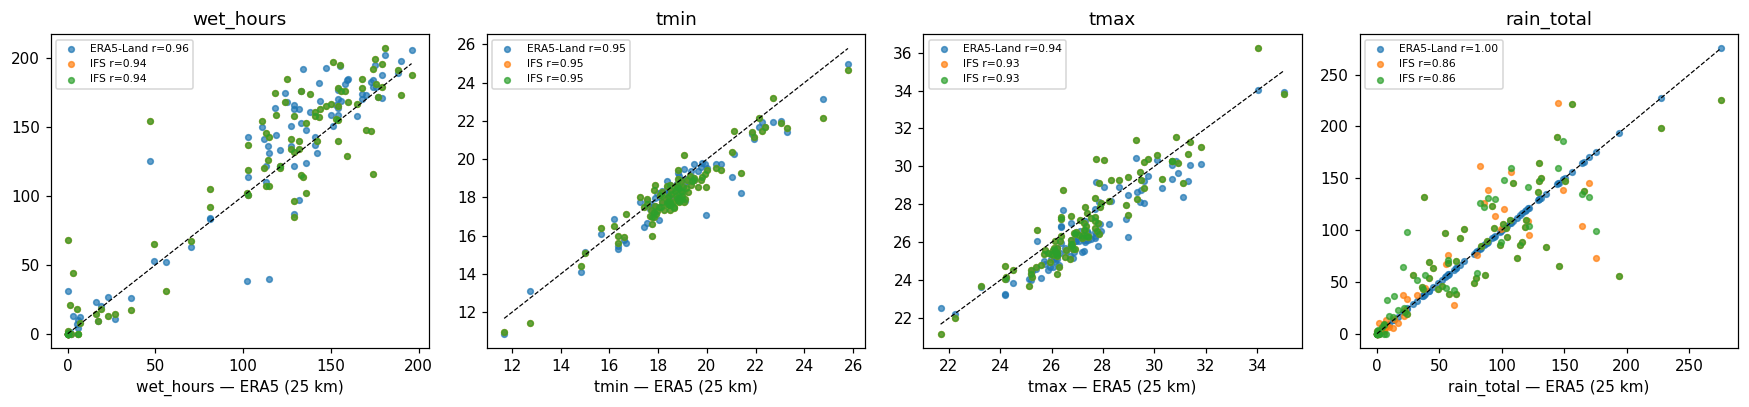

In [23]:
labels = list(FEATURE_SETS)
key = ['wet_hours', 'tmin', 'tmax', 'rain_total']
fig, ax = plt.subplots(1, len(key), figsize=(16, 3.8))
ref = labels[0]
for a, f in zip(ax, key):
    col = f'{ANCHOR_STAGE}_{f}'
    x = feature_tables[ref].set_index('env')[col]
    for lab in labels[1:]:
        y = feature_tables[lab].set_index('env')[col].reindex(x.index)
        a.scatter(x, y, s=14, alpha=0.7, label=f'{lab.split(" (")[0]} r={x.corr(y):.2f}')
    lims = [np.nanmin(x), np.nanmax(x)]; a.plot(lims, lims, 'k--', lw=0.8)
    a.set_xlabel(f'{f} — {ref}'); a.set_title(f); a.legend(fontsize=7)
plt.tight_layout(); plt.show()

### How does each predictor relate to severity, per source? (Spearman correlation)

In [24]:
def sev_corr(t):
    m = env[['env', 'severity']].merge(t, on='env')
    return m[FEATURES].corrwith(m['severity'], method='spearman')
corr = pd.DataFrame({lab: sev_corr(t) for lab, t in feature_tables.items()})
corr.index = [c.split('_', 1)[1] for c in corr.index]
display(corr.loc[corr.abs().max(axis=1).sort_values(ascending=False).index].round(2)
            .style.background_gradient(cmap='RdBu_r', vmin=-0.6, vmax=0.6))

,ERA5 (25 km),ERA5-Land (11 km),IFS (9 km),IFS (9 km) + CHIRPS rain (5 km)
rh_mean,0.240000,0.310000,0.340000,0.340000
soilm,0.230000,0.330000,0.300000,0.300000
vpd_mean,-0.250000,-0.310000,-0.330000,-0.330000
wet_hours,0.190000,0.310000,0.310000,0.310000
infect_days,0.190000,0.300000,0.270000,0.270000
wet_days6,0.190000,0.300000,0.290000,0.290000
rain_days,0.290000,0.290000,0.290000,0.260000
tmax,-0.210000,-0.250000,-0.270000,-0.270000
hot_days,-0.190000,-0.220000,-0.250000,-0.250000
rain_total,0.210000,0.210000,0.250000,0.240000


## 7. Which weather source predicts rust best? (time-based validation)

Every feature set is tested the same way: **train on earlier years, test on the next year** (forward chaining).
The best source is the one with the lowest error on trials that actually had rust (`MAE_rust_envs`) and the highest `spearman`,
always compared with the baseline that ignores weather.

⚠️ Most trials had almost no rust, so a model that always says "no rust" already reaches high class accuracy.

,,n,MAE,RMSE,MAE_rust_envs,class_acc,within_1,spearman
source,model,,,,,,,
IFS (9 km) + CHIRPS rain (5 km),Random forest,83.0,0.460,0.696,1.180,0.747,0.916,0.190
IFS (9 km),Random forest,83.0,0.461,0.697,1.181,0.747,0.916,0.190
ERA5 (25 km),Random forest,83.0,0.498,0.714,1.206,0.675,0.916,0.133
ERA5-Land (11 km),Random forest,83.0,0.465,0.695,1.209,0.759,0.916,0.163
IFS (9 km) + CHIRPS rain (5 km),Ridge,83.0,0.494,0.709,1.233,0.747,0.904,0.203
IFS (9 km),Ridge,83.0,0.493,0.710,1.234,0.747,0.904,0.199
none,Baseline (mean),83.0,0.535,0.723,1.246,0.783,0.892,-0.072
ERA5-Land (11 km),Ridge,83.0,0.518,0.738,1.254,0.699,0.904,0.112
ERA5 (25 km),Ridge,83.0,0.562,0.782,1.303,0.663,0.904,-0.046


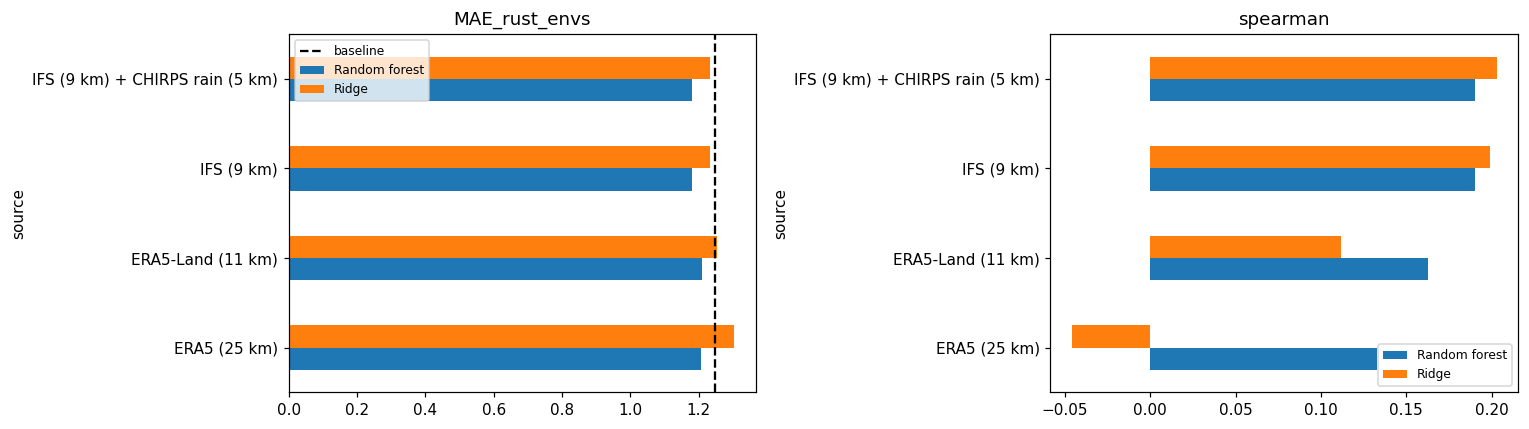

In [25]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from scipy.stats import spearmanr

MODELS = {
    'Baseline (mean)': lambda: DummyRegressor(strategy='mean'),
    'Ridge':           lambda: make_pipeline(SimpleImputer(strategy='median'), StandardScaler(), RidgeCV(alphas=np.logspace(-2, 3, 30))),
    'Random forest':   lambda: make_pipeline(SimpleImputer(strategy='median'),
                                             RandomForestRegressor(n_estimators=500, min_samples_leaf=4, max_features=0.5, random_state=42)),
}

def scores(g):
    return pd.Series({'n': len(g),
                      'MAE':  np.abs(g.obs - g.pred).mean(),
                      'RMSE': np.sqrt(((g.obs - g.pred) ** 2).mean()),
                      'MAE_rust_envs': np.abs(g.obs - g.pred)[g.obs >= 1.5].mean(),
                      'class_acc': (g.obs.round() == g.pred.round()).mean(),
                      'within_1':  (np.abs(g.obs.round() - g.pred.round()) <= 1).mean(),
                      'spearman':  spearmanr(g.obs, g.pred)[0]})

all_preds = []
for label, t in feature_tables.items():
    md_ = env[['env', 'year', 'severity']].merge(t, on='env').dropna(subset=['severity'])
    X, y, years = md_[FEATURES], md_['severity'], md_['year']
    for ty in sorted(years.unique())[2:]:
        tr, te = years < ty, years == ty
        for name, make in MODELS.items():
            if name.startswith('Baseline') and label != list(FEATURE_SETS)[0]:
                continue                                      # baseline doesn't use weather: run once
            p = np.clip(make().fit(X[tr], y[tr]).predict(X[te]), 1, 5)
            all_preds.append(pd.DataFrame({'source': 'none' if name.startswith('Baseline') else label, 'model': name,
                                           'test_year': ty, 'env': md_.loc[te, 'env'], 'obs': y[te], 'pred': p}))
all_preds = pd.concat(all_preds)
comparison = all_preds.groupby(['source', 'model']).apply(scores).round(3).sort_values('MAE_rust_envs')
display(comparison)

cmp = comparison.drop(index='none', level=0).reset_index()
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for a, m in zip(ax, ['MAE_rust_envs', 'spearman']):
    cmp.pivot(index='source', columns='model', values=m).plot.barh(ax=a)
    if m == 'MAE_rust_envs':
        a.axvline(comparison.loc[('none', 'Baseline (mean)'), m], color='k', ls='--', label='baseline')
    a.set_title(m); a.legend(fontsize=8)
plt.tight_layout(); plt.show()

Best combination: IFS (9 km) + CHIRPS rain (5 km) + Random forest


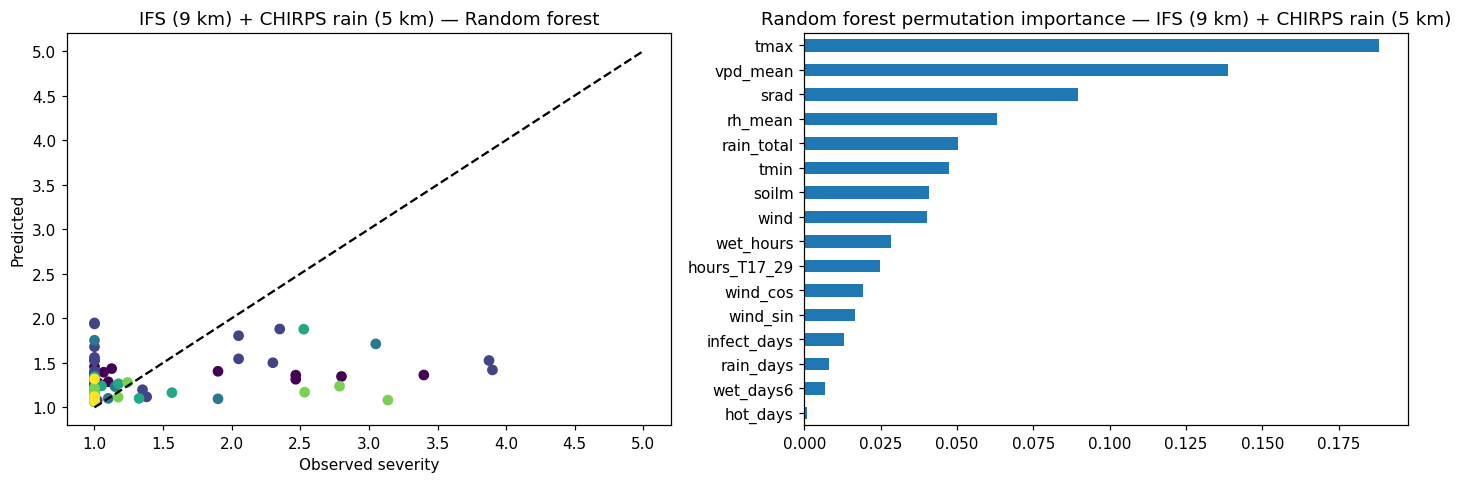

In [26]:
best_source, best_model = cmp.sort_values('MAE_rust_envs').iloc[0][['source', 'model']]
print(f'Best combination: {best_source} + {best_model}')
best = env[['env', 'severity']].merge(feature_tables[best_source], on='env').dropna(subset=['severity'])
p = all_preds[(all_preds.source == best_source) & (all_preds.model == best_model)]

from sklearn.inspection import permutation_importance
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].scatter(p.obs, p.pred, c=p.test_year, cmap='viridis'); ax[0].plot([1, 5], [1, 5], 'k--')
ax[0].set_xlabel('Observed severity'); ax[0].set_ylabel('Predicted'); ax[0].set_title(f'{best_source} — {best_model}')
final = MODELS['Random forest']().fit(best[FEATURES], best['severity'])
imp = permutation_importance(final, best[FEATURES], best['severity'], n_repeats=30, random_state=0)
pd.Series(imp.importances_mean, index=[f.split('_', 1)[1] for f in FEATURES]).sort_values().plot.barh(ax=ax[1])
ax[1].set_title(f'Random forest permutation importance — {best_source}')
plt.tight_layout(); plt.show()

## 8. From predicted severity to a risk alert (prototype)

Predicted severity is mapped to four tiers matching the scoring chart (1 = no rust, 2 = 1–10%, 3 = 11–35%, 4 = 36–65%, 5 = > 66% leaf area),
similar to the traffic-light alerts in Patel et al. (2026). Thresholds are placeholders to agree with pathologists.

In [27]:
def risk_tier(sev):
    if sev < 1.5: return 'Green – no/negligible rust expected'
    if sev < 2.5: return 'Yellow – light rust (1–10% leaf area); scout fields'
    if sev < 3.5: return 'Orange – moderate rust (11–35%); prepare to spray'
    return 'Red – severe rust (>35%); spray / protect susceptible varieties'

p = p.copy()
p['risk_tier'] = p['pred'].apply(risk_tier); p['observed_tier'] = p['obs'].apply(risk_tier)
print(f'{best_source} — {best_model}: tier agreement = {(p.risk_tier == p.observed_tier).mean():.3f}')
order = ['Green', 'Yellow', 'Orange', 'Red']
ct = pd.crosstab(p.observed_tier.str.split(' ').str[0], p.risk_tier.str.split(' ').str[0], rownames=['observed'], colnames=['predicted'])
display(ct.reindex(index=order, columns=order, fill_value=0))

IFS (9 km) + CHIRPS rain (5 km) — Random forest: tier agreement = 0.747


predicted,Green,Yellow,Orange,Red
observed,,,,
Green,58,7,0,0
Yellow,5,4,0,0
Orange,5,2,0,0
Red,1,1,0,0


## 9. Save outputs

In [28]:
short = lambda s: s.split(' (')[0].replace(' ', '_').replace('+', 'plus').lower()
saved = []
for label, t in feature_tables.items():
    f = f'sbr_features_{short(label)}{"_chirps" if "CHIRPS" in label else ""}.csv'
    env.merge(t, on='env').to_csv(f, index=False); saved.append(f)
geno.to_csv('sbr_genotype_level.csv', index=False)
comparison.to_csv('sbr_source_comparison.csv')
all_preds.to_csv('sbr_forward_chaining_predictions.csv', index=False)
saved += ['sbr_genotype_level.csv', 'sbr_source_comparison.csv', 'sbr_forward_chaining_predictions.csv']
print('Saved:', *saved, sep='\n  ')
try:
    from google.colab import files
    for f in ['sbr_source_comparison.csv'] + saved[:len(feature_tables)]:
        files.download(f)
except ImportError:
    pass

Saved:
  sbr_features_era5.csv
  sbr_features_era5-land.csv
  sbr_features_ifs.csv
  sbr_features_ifs_chirps.csv
  sbr_genotype_level.csv
  sbr_source_comparison.csv
  sbr_forward_chaining_predictions.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Notes and next steps

* **Small sample:** about 100 environments, and many had little rust. Differences between sources can be small and partly due to chance; look for consistency across years, not a single best number.
* **Higher resolution is not automatically better.** The comparison in Section 7 is the evidence for choosing a source in the thesis.
* **IFS consistency:** the IFS model is upgraded over time; that matters little for 2017–2025 but should be mentioned as a limitation.
* **Forecast mode:** training on IFS keeps the model consistent with ECMWF forecasts that the operational system would use for the next 14 days.
* **Zeros / symptom date:** re-run with `ZERO_HANDLING = 'drop'` and with `ANCHOR_STAGE = 'R6'` to test sensitivity.
* **Station validation:** if station data from DCCMS (Malawi) or ZMD (Zambia) become available, compare them with each gridded source.